In [1]:
import pandas as pd
import numpy as np
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal

In [2]:
def get_size_factors_and_dar(count_matrix, metadata, design="tech_plus_study + sex + age_disease_status",
    reference="postnatal:N", n_cpus=16):
    '''Compute size factors and run DAR/DE for all age_disease_status
    contrasts vs. postnatal:N.'''

    metadata = metadata.copy()

    # construct composite condition
    metadata["age_disease_status"] = (metadata["age_status"].astype(str) + ":" + metadata["disease_binary"].astype(str))

    # ensure categorical + set reference
    metadata["age_disease_status"] = pd.Categorical(metadata["age_disease_status"],
        categories=sorted(metadata["age_disease_status"].unique()),)
    metadata["age_disease_status"] = metadata["age_disease_status"].cat.reorder_categories(
        [reference] + [c for c in metadata["age_disease_status"].cat.categories if c != reference],
        ordered=True)

    # fit DESeq2 model
    dds = DeseqDataSet(counts=count_matrix,metadata=metadata,design=design,refit_cooks=True,n_cpus=n_cpus)
    dds.deseq2()

    # run contrasts
    results = []

    for level in metadata["age_disease_status"].cat.categories:
        if level == reference:
            continue

        stat_res = DeseqStats(dds, contrast=("age_disease_status", level, reference), n_cpus=n_cpus)
        stat_res.summary()

        res = stat_res.results_df.copy()
        res["contrast"] = f"{level}_vs_{reference}"
        results.append(res)

    results_df = pd.concat(results, axis=0)

    return dds, results_df

In [3]:
def find_closest_peak_from_string(dds, snp_chr, snp_pos, peak_col=None, n_closest=1):
    '''
    Find closest peak(s) to a SNP when dds.var index or a column contains peak coordinates as strings:  e.g. "chr1:794224-794725".
    '''
    
    # use peak strings from column or index
    if peak_col is None:
        peak_strings = dds.var.index.to_series().copy()
    else:
        peak_strings = dds.var[peak_col].copy()

    # parse chrom, start, end
    peaks = peak_strings.str.split("[:-]", expand=True)
    peaks.columns = ["chrom", "start", "end"]
    peaks["start"] = peaks["start"].astype(int)
    peaks["end"] = peaks["end"].astype(int)
    peaks["peak_str"] = peak_strings

    # subset by chromosome
    peaks_chr = peaks[peaks["chrom"] == snp_chr].copy()
    if peaks_chr.empty:
        raise ValueError(f"No peaks found on chromosome {snp_chr}")

    # compute distance to SNP
    peaks_chr["distance"] = np.where(
        snp_pos < peaks_chr["start"],
        peaks_chr["start"] - snp_pos,
        np.where(
            snp_pos > peaks_chr["end"],
            snp_pos - peaks_chr["end"],
            0  # SNP overlaps peak
        )
    )

    # sort by distance
    return peaks_chr.sort_values("distance").head(n_closest)

In [4]:
def plot_gene_violin_pydeseq2(
    dds, gene, x_col, log_transform=True, pseudocount=1, figsize=(6, 4)):
    '''
    Violin + boxplot for a gene using PyDESeq2 normalized counts.
    Optionally test significance between groups and annotate.
    ''' 
    
    # extract expression
    gene_idx = np.where(dds.var_names == gene)[0][0]
    expr = dds.layers["normed_counts"][:, gene_idx]

    # plotting dataframe
    plot_df = dds.obs.copy()
    plot_df["expression"] = expr
    if log_transform:
        plot_df["expression"] = np.log2(plot_df["expression"] + pseudocount)

    # produce plot
    plt.figure(figsize=figsize)
    sns.violinplot(data=plot_df, x=x_col, y="expression", inner=None, color="#e6e6e6", linewidth=1)
    sns.boxplot(data=plot_df, x=x_col,y="expression", width=0.2,showcaps=True,
        boxprops={"facecolor": "white", "edgecolor": "black"}, whiskerprops={"color": "black"},
        medianprops={"color": "red"}, showfliers=False)
    sns.stripplot(data=plot_df, x=x_col, y="expression", color="black", size=3, alpha=0.6, jitter=0.15)

    plt.xlabel(x_col)
    plt.ylabel(f"log2(normalized counts + {pseudocount})" if log_transform else "Normalized counts")
    plt.title(gene)
    sns.despine()
    plt.tight_layout()
    
    return(plot_df, plt)

### ADAMTS7 is differentially expressed in endothelial cells 

- Higher expression in fetal
- Higher expression in HCM

Now, check the scE2G linkage in Endothelial cells

In [6]:
scE2G_Endo_links = pd.read_csv("intersecting_SNPs/Endothelial_loci_intersections.csv")

filt_scE2G_Endo_links = scE2G_Endo_links.loc[:,["name", "TargetGene", "lead_SNP", "disease", "candidate_SNP", "RNA_pseudobulkTPM",
                             "CellType", "prioritized_gene", "E2G.Score", "locus"] ]

Endo_gene_name = "ADAMTS7"

In [7]:
filt_scE2G_Endo_links.loc[filt_scE2G_Endo_links['TargetGene'] == Endo_gene_name, ]

,name,TargetGene,lead_SNP,disease,candidate_SNP,RNA_pseudobulkTPM,CellType,prioritized_gene,E2G.Score,locus
120,intergenic|chr15:78750523-78751447,ADAMTS7,chr15:78760672-78760672,HCM,chr15:78750846-78750846,13.386648,Endothelial,ADAMTS7/MORF4L1,0.325740,chr15:78760672-78760672
121,intergenic|chr15:78750523-78751447,ADAMTS7,chr15:78760672-78760672,HCM,chr15:78751238-78751238,13.386648,Endothelial,ADAMTS7/MORF4L1,0.325740,chr15:78760672-78760672
122,intergenic|chr15:78750523-78751447,ADAMTS7,chr15:78760672-78760672,HCM,chr15:78751333-78751333,13.386648,Endothelial,ADAMTS7/MORF4L1,0.325740,chr15:78760672-78760672
126,genic|chr15:78759963-78760712,ADAMTS7,chr15:78760672-78760672,HCM,chr15:78760413-78760413,13.386648,Endothelial,ADAMTS7/MORF4L1,0.506209,chr15:78760672-78760672
127,genic|chr15:78759963-78760712,ADAMTS7,chr15:78760672-78760672,HCM,chr15:78760672-78760672,13.386648,Endothelial,ADAMTS7/MORF4L1,0.506209,chr15:78760672-78760672
130,genic|chr15:78761096-78761988,ADAMTS7,chr15:78760672-78760672,HCM,chr15:78761766-78761766,13.386648,Endothelial,ADAMTS7/MORF4L1,0.705174,chr15:78760672-78760672
132,genic|chr15:78779183-78781191,ADAMTS7,15:78790089,DCM,chr15:78779619-78779619,13.386648,Endothelial,ADAMTS7,0.686325,ADAMTS7_locus0


In [8]:
%%time
Endo_ATAC_count_matrix = pd.read_csv("../../../../ATAC/aggregated_analysis/pseudobulked_analysis/pseudobulked_counts/Endothelial_count_matrix.csv", index_col = 0)
Endo_ATAC_metadata = pd.read_csv("../../../../ATAC/aggregated_analysis/pseudobulked_analysis/pseudobulked_counts/Endothelial_metadata.csv", index_col = 0)

CPU times: user 23.3 s, sys: 2.15 s, total: 25.5 s
Wall time: 25.4 s


In [9]:
%%time
Endo_dds, Endo_DAR_res = get_size_factors_and_dar(count_matrix = Endo_ATAC_count_matrix, metadata = Endo_ATAC_metadata)

/home/william/anaconda3/envs/r-kernel/lib/python3.12/functools.py:907: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 1.10 seconds.

Fitting dispersions...
... done in 18.78 seconds.

Fitting dispersion trend curve...
... done in 2.82 seconds.

Fitting MAP dispersions...
... done in 17.17 seconds.

Fitting LFCs...
... done in 14.93 seconds.

Calculating cook's distance...
... done in 3.09 seconds.

Replacing 5 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.02 seconds.

Running Wald tests...
... done in 8.70 seconds.



Log2 fold change & Wald test p-value: age_disease_status fetal:N vs postnatal:N
                         baseMean  log2FoldChange     lfcSE      stat  \
chr1:794224-794725       4.070465        0.608879  0.261498  2.328427   
chr1:794869-795370      14.935256       -0.221864  0.199985 -1.109399   
chr1:806996-807497       4.026616       -0.490585  0.317849 -1.543451   
chr1:807687-808188       4.596704        0.279311  0.292729  0.954164   
chr1:814556-815057       2.467497        0.331369  0.296726  1.116751   
...                           ...             ...       ...       ...   
chrY:20574903-20575404   3.543018       -0.042436  0.374414 -0.113339   
chrY:21702831-21703332   5.850805       -3.590303  0.655632 -5.476097   
chrY:21705255-21705756   3.547792       -3.108177  0.713274 -4.357617   
chrY:22123981-22124482   2.750256       -1.637679  0.726772 -2.253361   
chrY:22461930-22462431   2.986804       -1.655276  0.729036 -2.270501   

                              pvalue       

Running Wald tests...
... done in 8.57 seconds.



Log2 fold change & Wald test p-value: age_disease_status postnatal:Y vs postnatal:N
                         baseMean  log2FoldChange     lfcSE      stat  \
chr1:794224-794725       4.070465       -0.181595  0.719945 -0.252234   
chr1:794869-795370      14.935256       -0.573276  0.441278 -1.299128   
chr1:806996-807497       4.026616        0.639968  1.453534  0.440285   
chr1:807687-808188       4.596704        0.698033  0.989682  0.705311   
chr1:814556-815057       2.467497       -0.427349  1.227886 -0.348037   
...                           ...             ...       ...       ...   
chrY:20574903-20575404   3.543018        0.856533  0.624934  1.370598   
chrY:21702831-21703332   5.850805        0.307237  0.645722  0.475803   
chrY:21705255-21705756   3.547792        0.413022  0.680952  0.606537   
chrY:22123981-22124482   2.750256        0.412376  1.623094  0.254068   
chrY:22461930-22462431   2.986804        0.418324  1.624547  0.257502   

                          pvalue      p

In [10]:
# get the closest peak to the scE2G linkage
Endo_closest_peak = find_closest_peak_from_string(Endo_dds, snp_chr="chr14", snp_pos=71540027).peak_str[0]

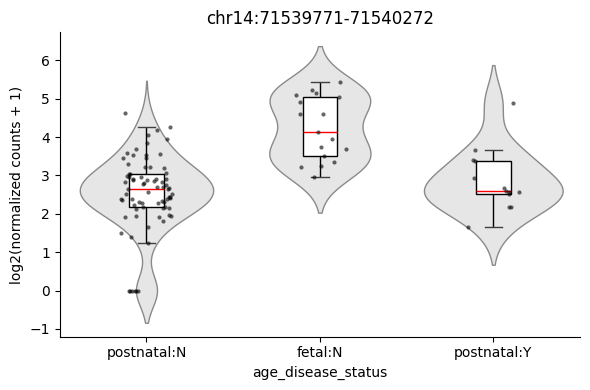

In [11]:
Endo_df, Endo_plot = plot_gene_violin_pydeseq2(Endo_dds, gene = Endo_closest_peak, x_col = "age_disease_status")

In [12]:
Endo_df.to_csv("03C_ADAMTS7_ATAC_df.csv")

In [13]:
Endo_DAR_res.loc[Endo_closest_peak]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,contrast
chr14:71539771-71540272,8.566452,1.723835,0.243754,7.072019,1.526956e-12,2.885097e-11,fetal:N_vs_postnatal:N
chr14:71539771-71540272,8.566452,-0.068764,0.517778,-0.132806,8.943470e-01,9.864591e-01,postnatal:Y_vs_postnatal:N


### DTL has higher expression in CMs, now check chromatin accessibility

In [14]:
scE2G_CM_links = pd.read_csv("intersecting_SNPs/Cardiomyocyte_loci_intersections.csv")

filt_scE2G_CM_links = scE2G_CM_links.loc[:,["name", "TargetGene", "lead_SNP", "disease", "candidate_SNP", "RNA_pseudobulkTPM",
                             "CellType", "prioritized_gene", "E2G.Score", "locus"] ]

In [15]:
%%time
CM_ATAC_count_matrix = pd.read_csv("../../../../ATAC/aggregated_analysis/pseudobulked_analysis/pseudobulked_counts/Cardiomyocyte_count_matrix.csv", index_col = 0)
CM_ATAC_metadata = pd.read_csv("../../../../ATAC/aggregated_analysis/pseudobulked_analysis/pseudobulked_counts/Cardiomyocyte_metadata.csv", index_col = 0)

CPU times: user 30.3 s, sys: 1.63 s, total: 32 s
Wall time: 32 s


In [16]:
%%time
CM_dds, CM_dar_res = get_size_factors_and_dar(count_matrix = CM_ATAC_count_matrix, metadata = CM_ATAC_metadata)

/home/william/anaconda3/envs/r-kernel/lib/python3.12/functools.py:907: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 1.67 seconds.

Fitting dispersions...
... done in 21.48 seconds.

Fitting dispersion trend curve...
... done in 3.61 seconds.

Fitting MAP dispersions...
... done in 21.16 seconds.

Fitting LFCs...
... done in 17.56 seconds.

Calculating cook's distance...
... done in 2.79 seconds.

Replacing 19 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.04 seconds.

Running Wald tests...
... done in 10.23 seconds.



Log2 fold change & Wald test p-value: age_disease_status fetal:N vs postnatal:N
                          baseMean  log2FoldChange     lfcSE       stat  \
chr1:794869-795370       17.597958       -1.791696  0.210913  -8.494948   
chr1:817172-817673       21.629334       -2.719544  0.190905 -14.245529   
chr1:827336-827837      312.057284       -0.011351  0.081040  -0.140062   
chr1:830697-831198       57.587000       -1.082977  0.170611  -6.347629   
chr1:831206-831707       61.981539        0.562766  0.129089   4.359534   
...                            ...             ...       ...        ...   
chrY:26308269-26308770   14.544841       -1.848031  0.374629  -4.932963   
chrY:26314999-26315500   22.123495       -0.991200  0.251358  -3.943379   
chrY:26359796-26360297   20.289884       -1.630687  0.355746  -4.583852   
chrY:26360411-26360912   22.032386       -0.927918  0.317949  -2.918449   
chrY:26524967-26525468   15.064032       -4.478077  0.623425  -7.183021   

                   

Running Wald tests...
... done in 11.29 seconds.



Log2 fold change & Wald test p-value: age_disease_status postnatal:Y vs postnatal:N
                          baseMean  log2FoldChange     lfcSE      stat  \
chr1:794869-795370       17.597958       -0.231398  0.402534 -0.574853   
chr1:817172-817673       21.629334       -0.087085  0.285718 -0.304792   
chr1:827336-827837      312.057284        0.157938  0.153712  1.027495   
chr1:830697-831198       57.587000        0.849695  0.323285  2.628314   
chr1:831206-831707       61.981539        0.038055  0.242940  0.156643   
...                            ...             ...       ...       ...   
chrY:26308269-26308770   14.544841        0.175161  0.776061  0.225705   
chrY:26314999-26315500   22.123495        0.383618  0.450477  0.851582   
chrY:26359796-26360297   20.289884        0.676556  0.608756  1.111374   
chrY:26360411-26360912   22.032386        0.003608  0.571914  0.006309   
chrY:26524967-26525468   15.064032        1.374000  0.710497  1.933858   

                          p

In [17]:
CM_gene_name = "DTL"
filt_scE2G_CM_links[filt_scE2G_CM_links['TargetGene'] == CM_gene_name]

,name,TargetGene,lead_SNP,disease,candidate_SNP,RNA_pseudobulkTPM,CellType,prioritized_gene,E2G.Score,locus
276,promoter|chr1:212034587-212036184,DTL,1:211933964,DCM,chr1:212036025-212036025,0.944573,Cardiomyocyte,DTL,0.89805,DTL_locus0


In [18]:
# get the closest peak to the scE2G linkage
CM_closest_peak = find_closest_peak_from_string(CM_dds, snp_chr="chr1", snp_pos=211933964)['peak_str'][0]

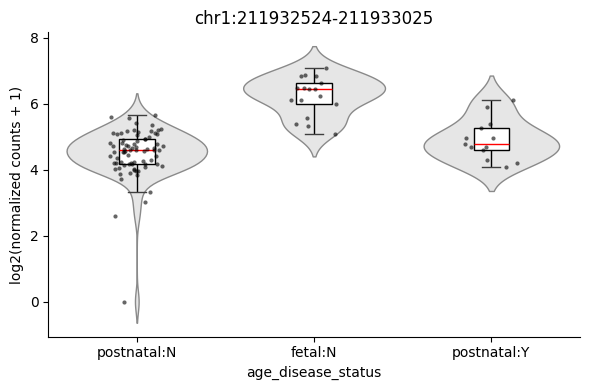

In [20]:
CM_plot_df, CM_plot = plot_gene_violin_pydeseq2(CM_dds, gene = CM_closest_peak, x_col = "age_disease_status")

In [21]:
CM_dar_res.loc[CM_closest_peak]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,contrast
chr1:211932524-211933025,33.572221,1.599449,0.149682,10.685625,1.188461e-26,9.198803e-26,fetal:N_vs_postnatal:N
chr1:211932524-211933025,33.572221,0.031760,0.290511,0.109326,9.129443e-01,9.904921e-01,postnatal:Y_vs_postnatal:N


In [22]:
CM_plot_df.to_csv("03C_DTL_ATAC_df.csv")